count    968.000000
mean       3.076678
std        1.860773
min        0.835415
25%        1.877740
50%        2.689619
75%        3.537081
max       18.100110
Name: total_execution_time_min, dtype: float64
count    32.000000
mean     14.030952
std       6.279665
min       5.465570
25%       9.697029
50%      11.851226
75%      17.026284
max      31.943698
Name: total_execution_time_min, dtype: float64


/tmp/ipykernel_579203/3252867049.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)


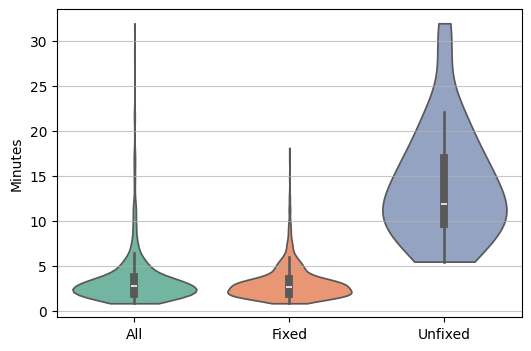

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


def nano_to_second(time_in_nano: float):
    return round(time_in_nano / 1_000_000_000, 4)


### Time plot for fixed/unfixed


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = nano_to_second(
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 60


print(evaluation_results_df[evaluation_results_df["plausibleFix"]]["total_execution_time_min"].describe())
print(evaluation_results_df[~evaluation_results_df["plausibleFix"]]["total_execution_time_min"].describe())


evaluation_results_df["category"] = np.where(
    evaluation_results_df["plausibleFix"], "Fixed", "Unfixed"
)

category_order = ["All", "Fixed", "Unfixed"]

all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)





# Create violin plot
plt.figure(figsize=(6, 4))
sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order)

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/cca_time_fixed_unfixed")
plt.show()

count    520.000000
mean       2.751736
std        1.658856
min        0.841345
25%        1.753195
50%        2.363028
75%        3.232715
max       17.634856
Name: total_execution_time_min, dtype: float64
count    444.000000
mean       3.913648
std        3.481080
min        0.835415
25%        2.142676
50%        2.989335
75%        4.349892
max       31.943698
Name: total_execution_time_min, dtype: float64
count    36.000000
mean      7.184789
std       4.278289
min       1.754181
25%       3.357162
50%       6.308871
75%      10.755421
max      17.093150
Name: total_execution_time_min, dtype: float64


/tmp/ipykernel_579203/697492303.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order )


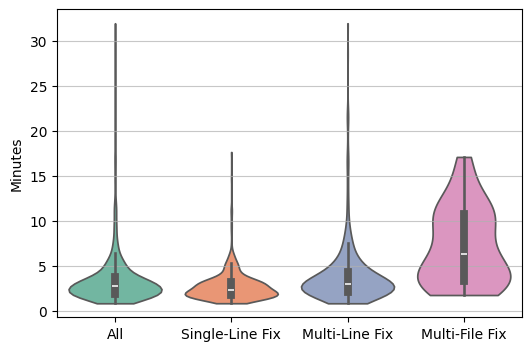

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np





### Time plot for single line / multi line / multi file


evaluation_results_df = pd.read_csv("../evaluation_results/evaluation_results_extended.csv")


evaluation_results_df["total_execution_time_min"] = (
    evaluation_results_df["executionTimeClassification"] +
    evaluation_results_df["executionTimeFixTP"] +
    evaluation_results_df["executionTimeFixFP"]
) / 1_000_000_000 / 60

evaluation_results_df["total_execution_time_min"] = evaluation_results_df["total_execution_time_min"].clip(lower=0)




evaluation_results_df["category"] = evaluation_results_df["fixComplexity"].map({
    "Single Line": "Single-Line Fix",
    "Multi Line": "Multi-Line Fix",
    "Multi File": "Multi-File Fix"
})

print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Single Line"]["total_execution_time_min"].describe())
print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Multi Line"]["total_execution_time_min"].describe())
print(evaluation_results_df[evaluation_results_df["fixComplexity"] == "Multi File"]["total_execution_time_min"].describe())

category_order = ["All", "Single-Line Fix", "Multi-Line Fix", "Multi-File Fix"]


all_df = evaluation_results_df.copy()
all_df["category"] = "All"

plot_df = pd.concat([all_df, evaluation_results_df], ignore_index=True)





# Create violin plot
plt.figure(figsize=(6, 4))
sns.violinplot(x="category", y="total_execution_time_min", data=plot_df, palette="Set2", cut=0, order=category_order )

plt.ylabel("Minutes")
plt.xlabel("")
plt.grid(axis='y', alpha=0.7)
plt.savefig("../evaluation_results/cca_time_per_fix_complexity")
plt.show()